In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
from google.colab import files

uploaded = files.upload()

Saving diamonds.csv to diamonds.csv


In [3]:
df = pd.read_csv("diamonds.csv")

In [4]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.shape

(53940, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [7]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [12]:
df.duplicated().sum()

np.int64(146)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(53794, 10)

In [17]:
df.describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [18]:
df.describe(include='object')

,cut,color,clarity
count,53794,53794,53794
unique,5,7,8
top,Ideal,G,SI1
freq,21488,11262,13032


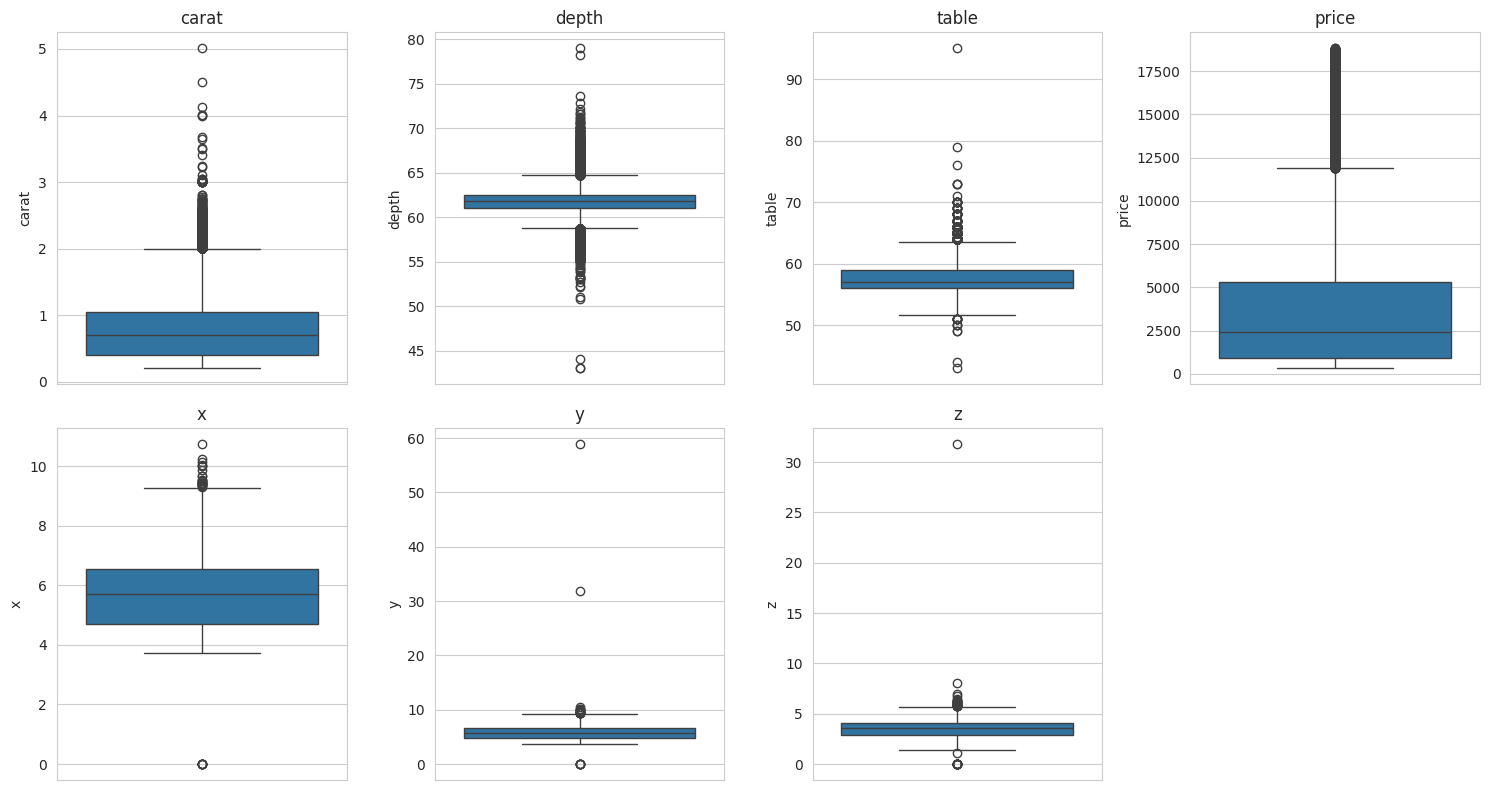

In [19]:
numerical = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
numerical = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

for col in numerical:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [21]:
df.shape

(46425, 10)

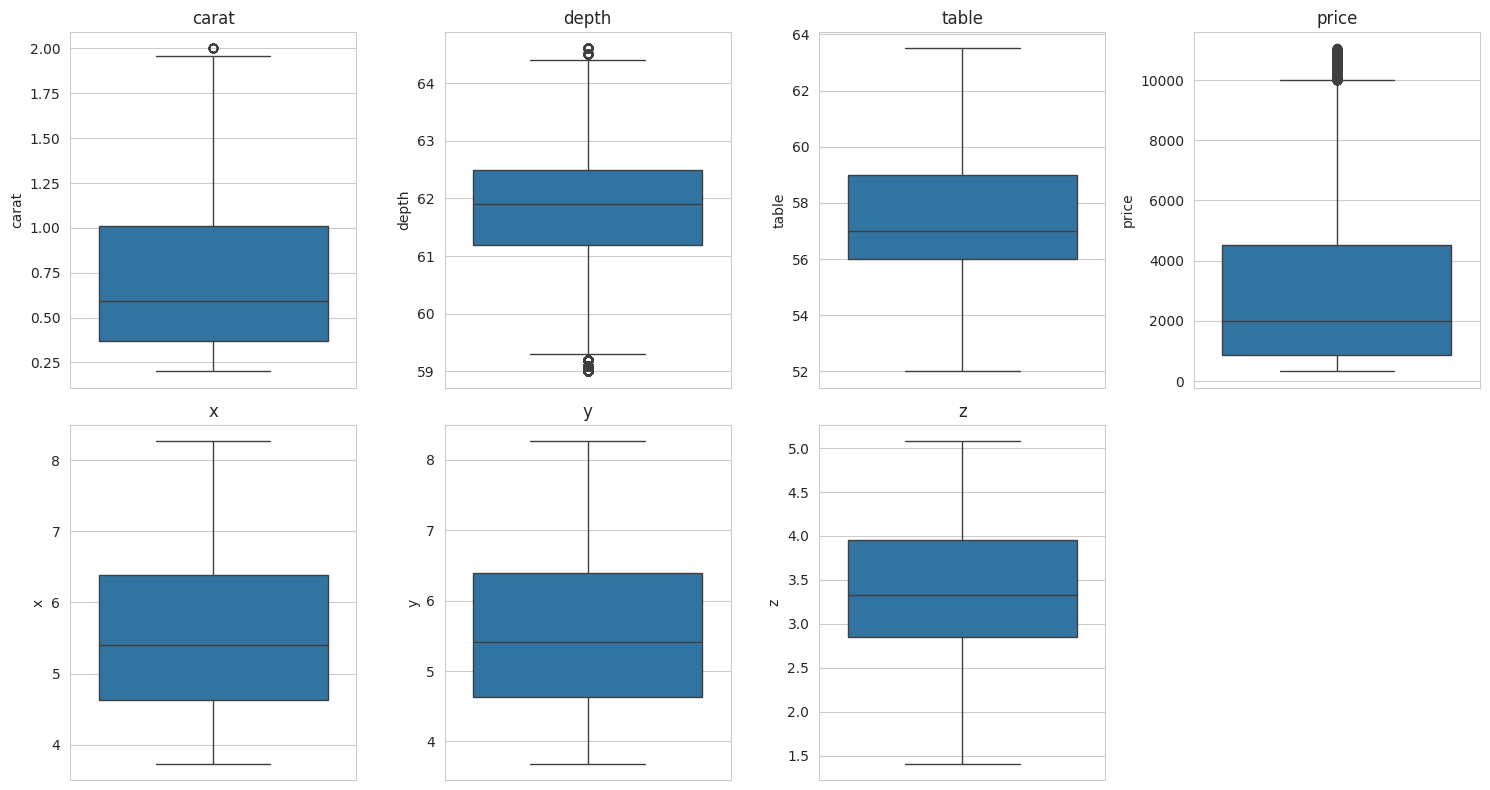

In [22]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

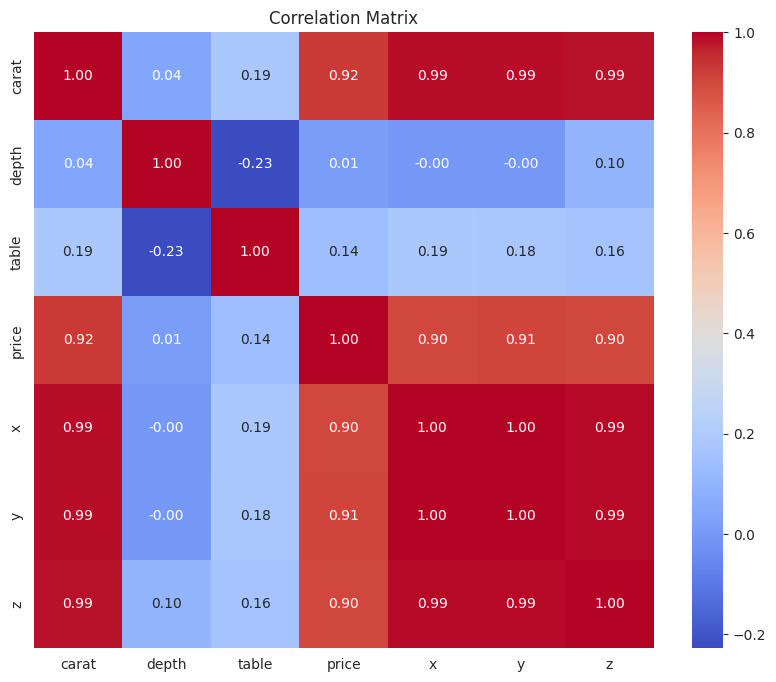

In [23]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

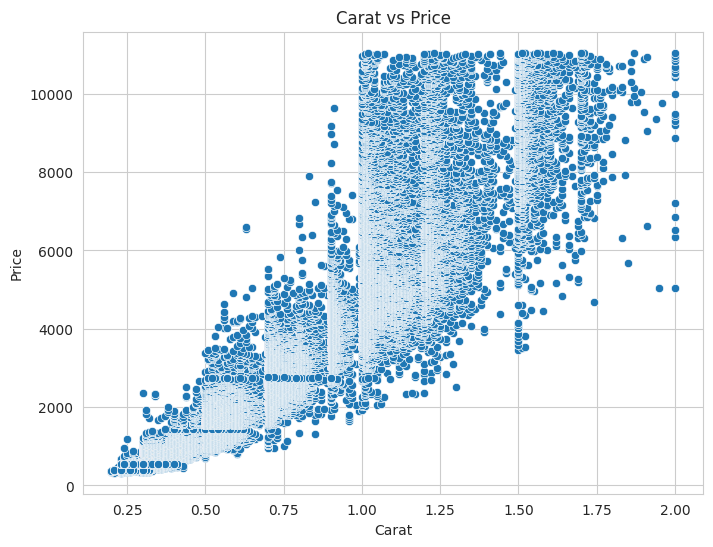

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='carat', y='price', data=df)

plt.title("Carat vs Price")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

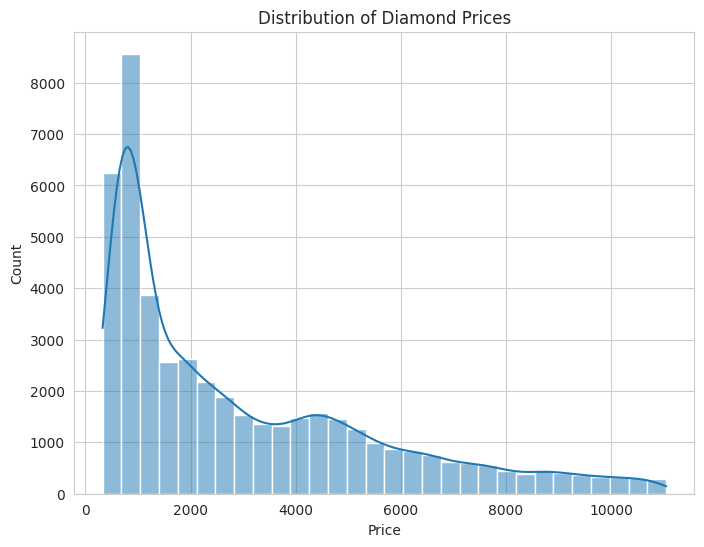

In [25]:
plt.figure(figsize=(8,6))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of Diamond Prices")
plt.xlabel("Price")
plt.show()

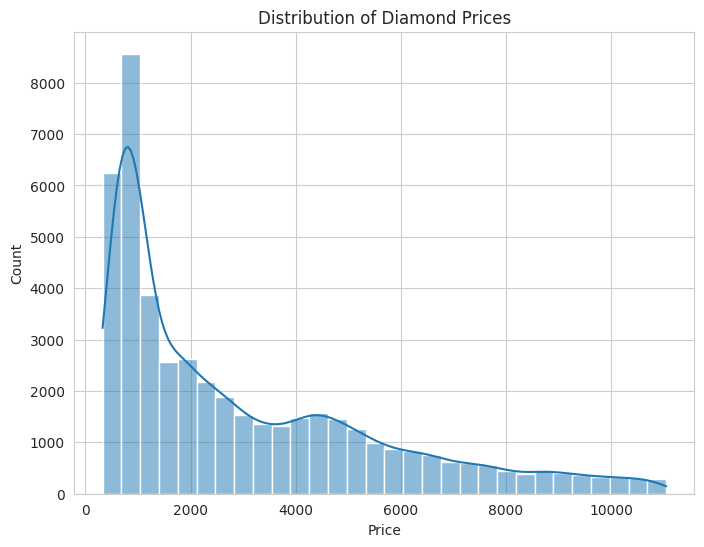

In [26]:
plt.figure(figsize=(8,6))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of Diamond Prices")
plt.xlabel("Price")
plt.show()

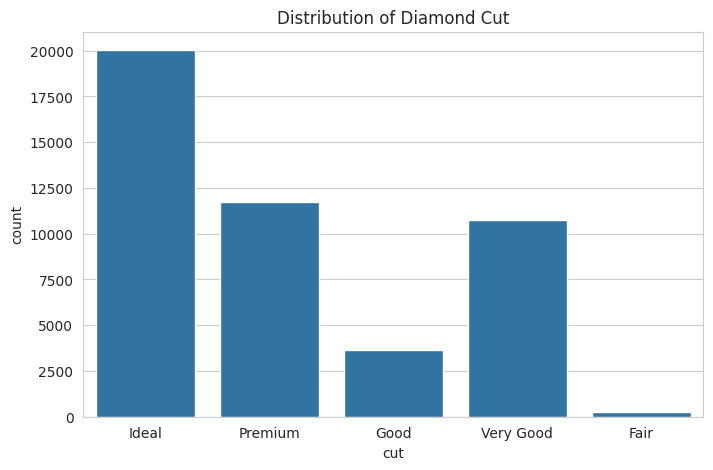

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x='cut', data=df)

plt.title("Distribution of Diamond Cut")
plt.show()

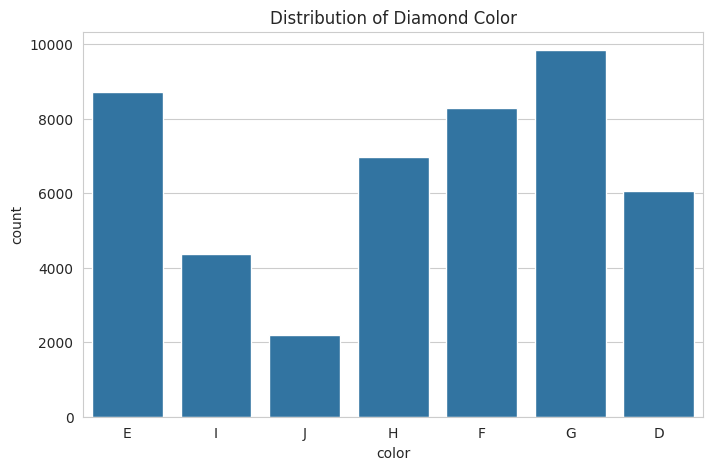

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x='color', data=df)

plt.title("Distribution of Diamond Color")
plt.show()

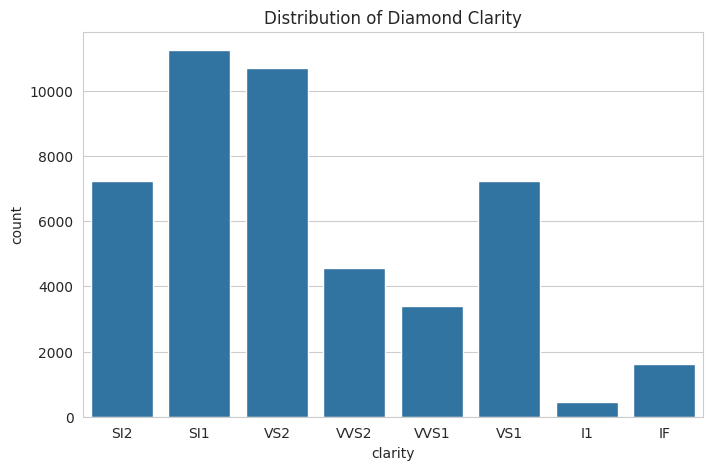

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(x='clarity', data=df)

plt.title("Distribution of Diamond Clarity")
plt.show()

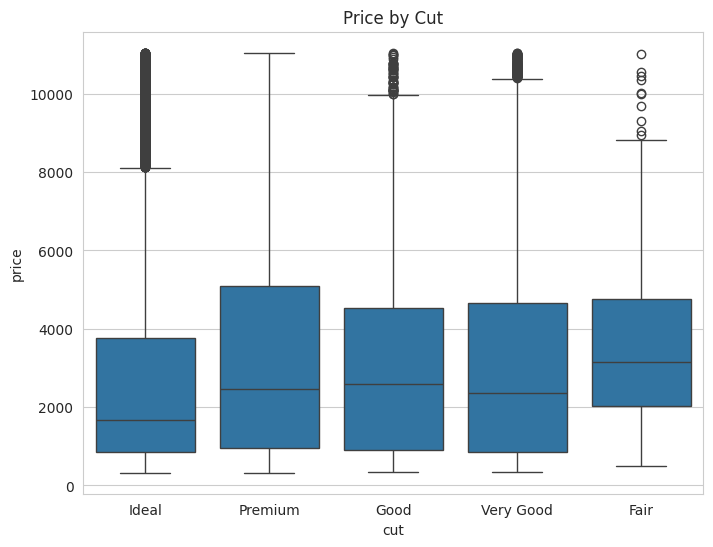

In [30]:
plt.figure(figsize=(8,6))

sns.boxplot(x='cut', y='price', data=df)

plt.title("Price by Cut")
plt.show()

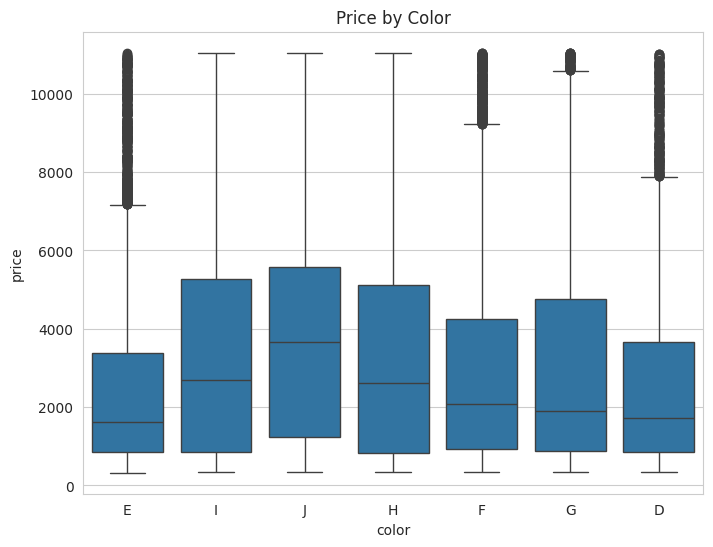

In [31]:
plt.figure(figsize=(8,6))

sns.boxplot(x='color', y='price', data=df)

plt.title("Price by Color")
plt.show()

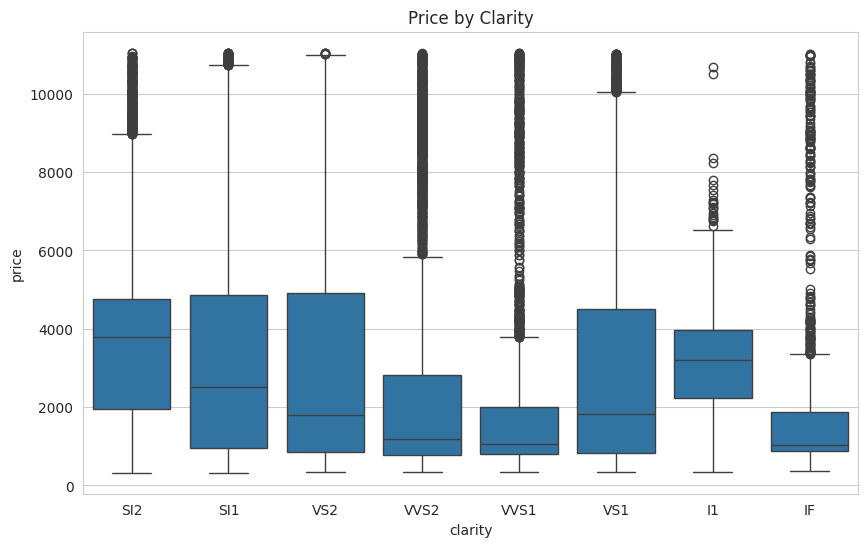

In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(x='clarity', y='price', data=df)

plt.title("Price by Clarity")
plt.show()

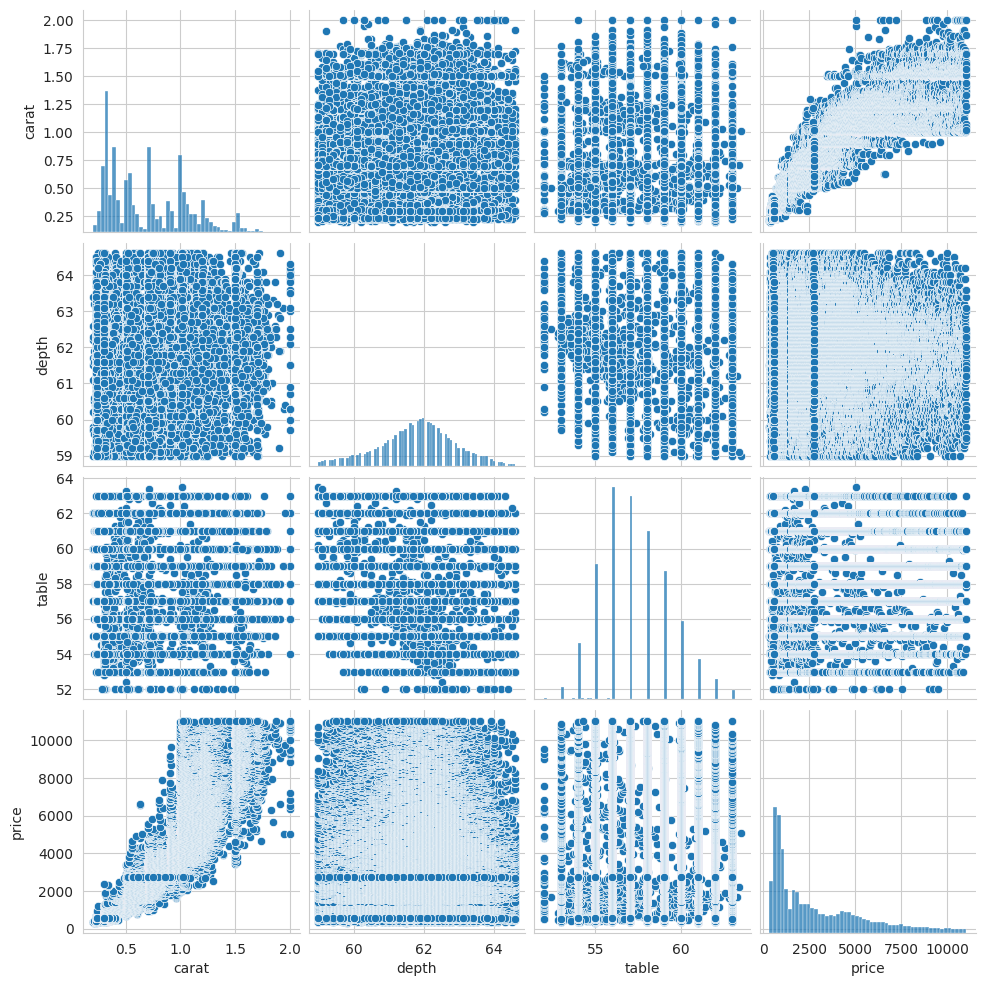

In [33]:
sns.pairplot(df[['carat', 'depth', 'table', 'price']])

plt.show()

In [34]:
print("Mean:\n")
print(df.mean(numeric_only=True))

print("\nMedian:\n")
print(df.median(numeric_only=True))

print("\nMode:\n")
print(df.mode().iloc[0])

print("\nStandard Deviation:\n")
print(df.std(numeric_only=True))

print("\nVariance:\n")
print(df.var(numeric_only=True))

Mean:

carat       0.698218
depth      61.803673
table      57.239968
price    3001.342768
x           5.522105
y           5.527182
z           3.414310
dtype: float64

Median:

carat       0.59
depth      61.90
table      57.00
price    2007.00
x           5.40
y           5.41
z           3.33
dtype: float64

Mode:

carat        0.3
cut        Ideal
color          G
clarity      SI1
depth       62.0
table       56.0
price        605
x           4.37
y           4.34
z            2.7
Name: 0, dtype: object

Standard Deviation:

carat       0.361951
depth       1.077656
table       2.013965
price    2599.798006
x           0.964303
y           0.958496
z           0.597123
dtype: float64

Variance:

carat    1.310087e-01
depth    1.161342e+00
table    4.056054e+00
price    6.758950e+06
x        9.298803e-01
y        9.187137e-01
z        3.565564e-01
dtype: float64


Objective:
To analyze how different features influence diamond prices using Exploratory Data Analysis (EDA).

Key Findings
The dataset was cleaned by removing unnecessary columns, duplicates, and outliers.
There were no missing values in the dataset.
Carat has the strongest positive correlation with price.
Diamonds with higher-quality cuts generally have higher prices.
Better clarity grades are associated with higher prices.
Color also influences price, but less strongly than carat and clarity.
Heatmap analysis shows that carat is the most influential numerical feature affecting diamond prices.
Conclusion

The analysis indicates that carat is the primary factor influencing diamond prices, while cut, clarity, and color also contribute significantly. These insights can help jewelry businesses with pricing strategies, inventory management, and customer recommendations.